# Day 2: Variational Monte Carlo for Fermionic Systems

Today we extend the VMC framework from Day 1 to study **interacting fermionic systems**.

We will work with the **t-V model** for spinless fermions on a 2D square lattice:

$$\hat{H} = -t \sum_{\langle i,j \rangle} (\hat{c}_i^\dagger \hat{c}_j + \hat{c}_j^\dagger \hat{c}_i) + V \sum_{\langle i,j \rangle} \hat{n}_i \hat{n}_j$$


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.sparse import lil_matrix
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh

torch.manual_seed(42)
np.random.seed(42)

## Problem 1: Jordan-Wigner Transformation

The Jordan-Wigner (JW) transformation maps fermionic operators to spin operators:

$$c_i^\dagger = \left(\prod_{j<i} -\sigma_j^z\right) \sigma_i^+, \qquad c_i = \left(\prod_{j<i} -\sigma_j^z\right) \sigma_i^-$$

We need to verify that these satisfy the **canonical anticommutation relations**:

$$\{c_i, c_j^\dagger\} = \delta_{ij}, \qquad \{c_i, c_j\} = \{c_i^\dagger, c_j^\dagger\} = 0$$


In [2]:
# Problem 1: Jordan-Wigner transformation (rough guideline)

# Define local spin operators and tensor-product helpers.
# Then construct c_i and c_i^\dagger from the JW string and local raising/lowering operators.

I2  = np.eye(2, dtype=complex)
sz  = np.array([[1, 0], [0, -1]], dtype=complex)
sp  = np.array([[0, 1], [0,  0]], dtype=complex)
sm  = np.array([[0, 0], [1,  0]], dtype=complex)

def kron_op(op, site, L):
    """Place a single-site operator on the chosen site of an L-site chain.
    Sites are labeled 0, 1, ..., L-1 .
    """
    # TODO: build the tensor product operator
    # all I2s that come before or after site multiply into an identity
    if site == 0:
        return np.kron(op, np.eye(2**(L-1)))
    
    if site == L-1:
        return np.kron(np.eye(2**(L-1)), op)
    
    if 0 < site and site < L:
        I_before_op = np.eye(2**site)
        I_after_op = np.eye(2**(L-1-site))
        return np.kron(I_before_op, np.kron(op, I_after_op))


def jw_c_dag(site, L):
    """Construct the fermionic creation operator using the JW transformation."""
    # TODO: combine the JW string with sigma^+ on the target site

    # no jw string for the first site
    if site == 0:
        return np.kron(sp, np.eye(2**(L-1)))
    
    # jw string as tensor product of -sz_j for all j<site 
    if 0 < site:
        c_dag = - np.copy(sz)
        for j in range(site-1):
            c_dag = np.kron(c_dag, -sz)
        c_dag = np.kron(c_dag, sp)

    # if site is not the last, tensor the rest with identities
    if site < L-1:
        c_dag = np.kron(c_dag, np.eye(2**(L-1-site)))
    
    return c_dag


def jw_c(site, L):
    """Construct the fermionic annihilation operator using the JW transformation."""
    # TODO: combine the JW string with sigma^- on the target site

    # no jw string for the first site
    if site == 0:
        return np.kron(sm, np.eye(2**(L-1)))
    
    # jw string as tensor product of -sz_j for all j<site 
    if 0 < site:
        c = - np.copy(sz)
        for j in range(site-1):
            c = np.kron(c, -sz)
        c = np.kron(c, sm)

    # if site is not the last, tensor the rest with identities
    if site < L-1:
        c = np.kron(c, np.eye(2**(L-1-site)))
    
    return c


In [4]:
jw_c(0, 3).real

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0.]])

In [5]:
# Problem 1: numerical check of anticommutation relations

# TODO:
# 1. Choose a small system size L.
# 2. Build all c_i and c_i^\dagger operators.
# 3. Check the canonical anticommutation relations numerically.
# 4. Compare the result to the expected identity/zero matrices.

def anticommutator(A, B):
    """Return {A, B} = AB + BA."""
    # TODO
    return A @ B + B @ A


L = 5
c_list = []
c_dag_list = []
for i in range(L):
    c_list += [jw_c(i, L)]
    c_dag_list += [jw_c_dag(i, L)]

I_L = np.eye(2**L, dtype=complex)
zero_L = np.zeros((2**L, 2**L), dtype=complex)

# check {c_i, c_j} = 0
for i in range(L):
    for j in range(L):
        c_i = c_list[i]
        c_j = c_list[j]
        anticomm = anticommutator(c_i, c_j)
        is_equal_zero = np.array_equal(anticomm, zero_L)
        if not is_equal_zero:
            print("{"+f"c_{i}, c_{j}"+"} =/= 0")

# check {c_dag_i, c_dag_j} = 0
for i in range(L):
    for j in range(L):
        c_dag_i = c_dag_list[i]
        c_dag_j = c_dag_list[j]
        anticomm = anticommutator(c_dag_i, c_dag_j)
        is_equal_zero = np.array_equal(anticomm, zero_L)
        if not is_equal_zero:
            print("{"+f"c_dag_{i}, c_dag_{j}"+"} =/= 0")

# check {c_i, c_dag_j} = delta_ij
for i in range(L):
    for j in range(L):
        c_i = c_list[i]
        c_dag_j = c_dag_list[j]
        anticomm = anticommutator(c_i, c_dag_j)
        delta_ij = I_L if i==j else zero_L
        is_equal_dij = np.array_equal(anticomm, delta_ij)
        if not is_equal_dij:
            print("{"+f"c_{i}, c_dag_{j}"+"} =/= delta_"+f"{i}{j}")


## Problem 2: The t-V Hamiltonian with Jordan-Wigner

We implement the t-V Hamiltonian for spinless fermions:

$$\hat{H} = -t \sum_{\langle i,j \rangle} (c_i^\dagger c_j + c_j^\dagger c_i) + V \sum_{\langle i,j \rangle} n_i n_j$$

For VMC we need Exact diagonalization (ED) to benchmark against

In [6]:
# Problem 2: Hilbert-space basis for spinless fermions

def build_fock_basis(L, N):
    """Return all occupation-number configurations with N fermions on L sites."""
    # TODO: generate all binary configurations with exactly N occupied sites
    configs = []
    # generate all combinations of N lattice sites beeing occupied and set them to 1 in the config vector
    for comb in combinations(range(L), N):
        config = np.zeros(L, dtype=int)
        config[list(comb)] = 1
        configs += [config]
    return np.array(configs)

def build_basis_dict(basis):
    """Map each basis configuration to its integer index in the basis list."""
    # TODO
    # enumerate all basis states and add both {idx:state} and {state:idx} to
    # dictionary for efficient conversion of both idx->state and state->idx
    basis_dict = {}
    for i, state in enumerate(basis):
        basis_dict |= {i:tuple(state), tuple(state):i}
    
    return basis_dict


def state_to_index(state, basis_dict):
    """Return the basis index of a given occupation configuration."""
    # TODO
    if type(state) is not np.ndarray:
        state = np.array(state)
    
    return basis_dict[tuple(state)]


def index_to_state(index, basis_dict):
    """Returns state for a given index."""
    return torch.tensor(basis_dict[index])


In [7]:
d = build_basis_dict(build_fock_basis(16, 4))
print(index_to_state(4, d))
state_to_index([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0], d)

tensor([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])


4

Lattice inexing used for the following part.

From coordinates $(x, y)$ of each lattice site, the lattice index is defined to 
be $i = x\cdot L_y + y$

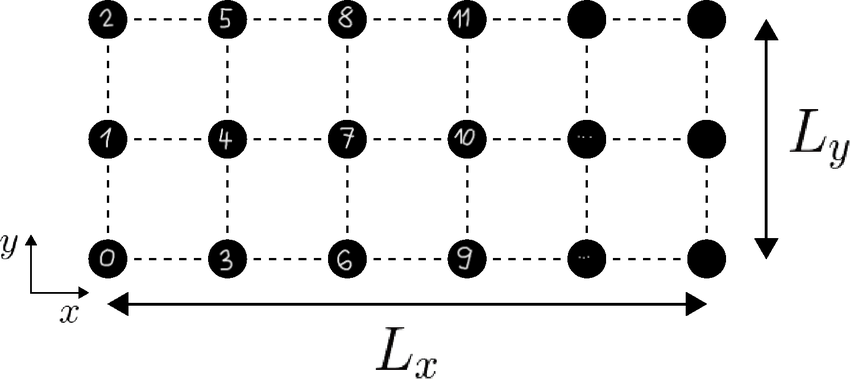

In [8]:
# Problem 2: t-V Hamiltonian with Jordan-Wigner signs
# The structure below is only an orientation; using it is optional!

def nearest_neighbor_bonds(Lx, Ly, pbc=True):
    """Return nearest-neighbor bonds for a square lattice with a chosen 1D ordering."""
    # TODO: define the lattice indexing and list all nearest-neighbor pairs
    nn_indices =[]
    for x in range(Lx):
        for y in range(Ly):
            # convert x,y coordinates to lattice site index
            i = x*Ly + y

            # right neighbor
            if x < Lx-1:
                j = i + Ly
                nn_indices += [(i, j)]
            elif pbc:
                j = y
                nn_indices += [(i, j)]

            # upper neighbor
            if y < Ly-1:
                j = i + 1
                nn_indices += [(i, j)]
            elif pbc:
                j = x*Ly
                nn_indices += [(i, j)]
    
    return nn_indices


def fermionic_hop_sign(state, i, j):
    """Return the sign associated with hopping a fermion from j to i."""
    # TODO: compute the Jordan-Wigner parity between the two sites
    # jw sign = (-1)**(# fermions between i and j)
    if i < j:
        return (-1)**np.sum(state[i+1:j])
    elif j < i:
        return (-1)**np.sum(state[j+1:i])
    else:
        return 1


def connected_elements_tv(state, bonds, t, V):
    """Return connected configurations and matrix elements for the t-V Hamiltonian."""
    # TODO:
    # - add diagonal density-density contributions
    # - add off-diagonal hopping contributions where allowed

    pass


def build_tv_hamiltonian(Lx, Ly, Nf, t, V, pbc=True):
    """Assemble the sparse t-V Hamiltonian in the fixed-particle-number Fock basis."""
    # TODO: build the basis, loop over states, and fill the sparse matrix
    basis = build_fock_basis(Lx*Ly, Nf)
    basis_dict = build_basis_dict(basis)
    nn_bonds = nearest_neighbor_bonds(Lx, Ly, pbc)
    H_rows = []
    H_cols = []
    H_data = []

    for s in basis:
        # diagonal V terms
        diag = 0.0
        for (i, j) in nn_bonds:
            diag += V * s[i] * s[j]
        
        s_idx = state_to_index(s, basis_dict)
        H_rows += [s_idx]
        H_cols += [s_idx]
        H_data += [diag]

        # offdiagonal t terms
        # get all lattice index pairs for which hopping can occur from a state s
        # i.e. nearest neighbor pairs with exactly one fermion
        hopping_pairs = [(i, j) for (i, j) in nn_bonds if s[i]+s[j] == 1]

        # compute state s_prime that is connected to s by nonzero matrix element
        for (i, j) in hopping_pairs:
            s_prime = np.copy(s)
            jw_sign = fermionic_hop_sign(s, i, j)

            # flip occupation number of i and j for hopping from i to j or j to i
            s_prime[i] = (s_prime[i] + 1) % 2
            s_prime[j] = (s_prime[j] + 1) % 2

            # matrix element <s'|H|s>
            mel = -t * jw_sign

            s_prime_idx = state_to_index(s_prime, basis_dict)
            H_cols += [s_idx]
            H_rows += [s_prime_idx]
            H_data += [mel]
        
    return coo_matrix((H_data, (H_rows, H_cols)), shape=(len(basis), len(basis)))


def groundstate_ed_tv(Lx, Ly, Nf, t, V, pbc=True):
    """Compute a small-system ED benchmark for the t-V model."""
    # TODO: diagonalize the sparse Hamiltonian and return the lowest states
    H = build_tv_hamiltonian(Lx, Ly, Nf, t, V, pbc)
    eigen = eigsh(H.tocsr(), 1, which="SA")
    ground_state = eigen[1][:,0]
    energy = eigen[0][0]
    return energy, ground_state


In [9]:
build_tv_hamiltonian(5,5,4, 1, 1, pbc=False)

<COOrdinate sparse matrix of dtype 'float64'
	with 154330 stored elements and shape (12650, 12650)>

In [10]:
H = build_tv_hamiltonian(3, 3, 4, 1, 1, pbc=False)
eigsh(H.tocsr(), 5, which="SA")[0]

array([-4.44352485, -4.36306121, -4.1575777 , -3.1209067 , -3.1209067 ])

In [11]:
Lx = 5
Ly = 5
Nf = 5
basis = build_fock_basis(Lx*Ly, Nf)
energy, state = groundstate_ed_tv(Lx, Ly, Nf, 1, 1, pbc=False)

In [12]:
state , energy

(array([ 1.38879849e-06, -2.39703454e-07, -5.98719049e-07, ...,
         1.42199461e-07, -2.39703454e-07,  1.38879849e-06], shape=(53130,)),
 np.float64(-12.123750107093805))

(array([[0.20087929, 0.21974753, 0.11469597, 0.21974753, 0.20087929],
        [0.21974753, 0.22651174, 0.18474779, 0.22651174, 0.21974753],
        [0.11469597, 0.18474779, 0.33468056, 0.18474779, 0.11469597],
        [0.21974753, 0.22651174, 0.18474779, 0.22651174, 0.21974753],
        [0.20087929, 0.21974753, 0.11469597, 0.21974753, 0.20087929]]),
 np.float64(5.000000000000009))

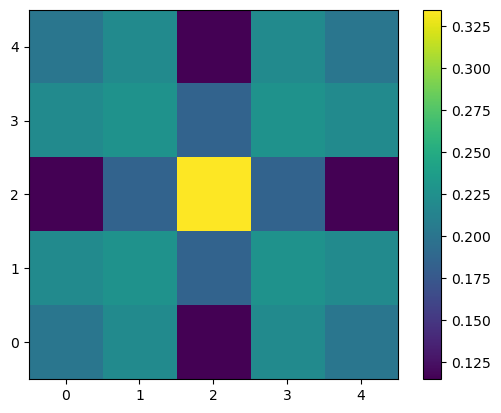

In [13]:
def plot_state(state, basis, Lx, Ly):
    """Plots the occupation probability of each lattice site for a given state."""

    # compute average lattice site occuptaion number
    avg_occ = np.zeros_like(basis[0], dtype=float)
    for prob, fock_state in zip(np.abs(state)**2, basis):
        avg_occ += prob * fock_state
    
    # reshape 1D array avg_occ to 2D array with dimensions of the lattice
    avg_occ = avg_occ.reshape(Lx, Ly)

    fig, ax = plt.subplots()
    im = ax.imshow(avg_occ.T, origin="lower")
    cbar = plt.colorbar(im)
    ax.set(xticks=np.arange(Lx), yticks=np.arange(Ly))
    
    return avg_occ, np.sum(avg_occ)



plot_state(state, basis, Lx, Ly)

## Problem 3: Slater Determinant Ansatz

The Slater determinant wavefunction is:

$$\psi(\sigma) = \det \tilde{A}(\sigma)$$

where $\tilde{A}(\sigma)$ is the $N \times N$ submatrix of $A$ (shape $L \times N$) obtained by selecting the rows corresponding to occupied orbitals.

The matrix $A$ contains all variational parameters.

In [14]:
# Problem 3: Slater determinant ansatz

class SlaterDeterminant(nn.Module):
    """Single-determinant variational wavefunction for fixed particle number."""

    def __init__(self, n_sites, n_fermions):
        super().__init__()
        self.n_sites = n_sites
        self.n_fermions = n_fermions

        # TODO: initialize the trainable orbital matrix A
        A0 = torch.randn(n_sites, n_fermions, dtype=float) 
        self.A = nn.Parameter(A0)


    def forward(self, sigmas):
        """Evaluate psi(sigma) for a batch of occupation-number configurations."""
        # TODO:
        # make sure sigma is a tensor
        # if type(sigmas) is not torch.Tensor:
        #     sigmas = torch.tensor(sigmas)

        psis = torch.zeros(len(sigmas), dtype=complex)
        
        for i, s in enumerate(sigmas):
            # 1. identify the occupied sites in each configuration
            occ_sites = torch.where(s == 1)[0]
            # make sure there are exactly n_fermions occupied sites
            if len(occ_sites) != self.n_fermions:
                raise ValueError("Number of occupied sites in configuration does"+
                                 " not match the number of fermions.")

            # 2. slice the corresponding rows of A
            A_sliced = self.A[occ_sites, :]

            # 3. return the determinant of the resulting square matrix
            psis[i] = torch.det(A_sliced)

        return psis


    def log_psi(self, sigmas):
        """Returns log of amplitude and phase of the wavefunction value for a given 
        list of state configurations. """
        psis = self.forward(sigmas)
        amp = torch.abs(psis)
        log_amp = torch.log(amp)
        phase = torch.angle(psis)
        return log_amp, phase

        
        

# Optional sanity check:
# - build a small Fock basis
# - evaluate the model on a few configurations
# - inspect the output shape
# basis = build_fock_basis(9, 2)
model = SlaterDeterminant(9, 2)

config = torch.tensor([1, 1, 0, 0, 0, 0, 0, 0, 0])
psi = model.forward([config])
log_amp, phase = model.log_psi([config])

In [262]:
# Problem 3/4: VMC training for fermionic ansätze

def propose_fermion_hop(state):
    """Propose a particle-number-conserving update."""
    # TODO
    occupied_sites = torch.where(state == 1)[0]
    empty_sites = torch.where(state == 0)[0]

    # pick a random occupied site to hop into a random empty site
    random_occupied = occupied_sites[np.random.randint(0, len(occupied_sites))]
    random_empty = empty_sites[np.random.randint(0, len(empty_sites))]
    prop = state.clone()
    prop[random_occupied] = 0
    prop[random_empty] = 1

    return prop


def metropolis_sampler_fermions(model, n_samples, n_burn, x0=None, basis_dict=None):
    """Sample configurations from |psi_theta(sigma)|^2."""
    # TODO: adapt the Day-1 Metropolis sampler to fixed-particle-number configurations
    if basis_dict is None:
        basis_dict = build_basis_dict(build_fock_basis(model.n_sites, model.n_fermions))
    
    if x0 is None:
        # TODO: fix particle number of randomly generated state
        n_states = len(basis_dict) // 2     # basis_dict contains each state twice 
                                            # {idx:state} and {state:idx}

        # take state corresponding to a random state index
        cur = basis_dict[np.random.randint(0, n_states)]
        cur = torch.tensor(cur)
    else:
        cur = x0.clone()

    with torch.no_grad():
        cur_prob = torch.abs(model.forward([cur]))**2

    # burn in
    for _ in range(n_burn):
        # propose update
        prop = propose_fermion_hop(cur)

        with torch.no_grad():
            psi_prop = model.forward([prop])
        
        # acceptance probability
        prop_prob = torch.abs(psi_prop)**2      # probability of proposed state
        acc = min(1, prop_prob / cur_prob)

        if np.random.rand() < acc:
            cur = prop
            cur_prob = prop_prob

    # sampling
    samples = []
    while len(samples) < n_samples:
        prop = propose_fermion_hop(cur)

        with torch.no_grad():
            psi_prop = model.forward([prop])
            prop_prob = torch.abs(psi_prop)**2

        # acceptance probability
        acc = min(1, prop_prob / cur_prob)

        if np.random.rand() < acc:
            cur = prop
            cur_prob = prop_prob
            samples += [state_to_index(cur, basis_dict)]
    
    samples = np.array(samples, dtype=int)
    return samples


def local_energy_tv(model, samples, H: coo_matrix, basis_dict=None):
    """Evaluate the local energy for the t-V model."""
    # TODO: use connected_elements_tv(...) and wavefunction ratios
    # all states here are represented by their index according to basis_dict
    if basis_dict is None:
        basis_dict = build_basis_dict(build_fock_basis(model.n_sites, model.n_fermions))

    n_samples = len(samples)
    E_loc = []

    for s in samples:
        # get all connected states s_prime

        # indices of coo_matrix lists where the row is s
        s_args = np.where(H.row == s)[0]

        # all s' that are connected to s via H
        s_primes = H.col[s_args]
        
        # matrix elements H_ss' for all s'
        H_ss_primes = H.data[s_args]
        
        # get state configuration from state index s
        state = index_to_state(s, basis_dict)
        # evaluate psi(s) with model
        # with torch.no_grad():
        psi_s = model.forward([state])

        # evaluate psi(s') and compute local energy contribution with H_ss'
        # for all connected s'
        E_ss_prime = []
        for s_prime, H_ss_prime in zip(s_primes, H_ss_primes):
            state_prime = index_to_state(s_prime, basis_dict)
            # with torch.no_grad():
            psi_s_prime = model.forward([state_prime])

            E_ss_prime += [H_ss_prime * psi_s_prime / psi_s]
        
        E_loc += [torch.sum(torch.tensor(E_ss_prime, dtype=float))]

    return torch.tensor(E_loc)


def _flatten_parameter_grads(params):
    """
    Helper: collect all parameter gradients into one flat vector.

    PyTorch stores gradients parameter by parameter in p.grad.
    For the VMC formula it is convenient to concatenate them into
    one vector indexed by k.
    """
    pieces = []
    for p in params:
        if p.grad is None:
            pieces.append(torch.zeros(p.numel(), dtype=p.dtype)) #if a parameter has no gradient we append a zero vector to maintain the correct shape
        else:
            pieces.append(p.grad.flatten())                      #flatten the gradient of this parameter and append to the list   
    return torch.cat(pieces).detach().clone()                    # concatenate all pieces into one flat vector and detach from the computation graph


def set_model_grad(model, flat_grad):
    """
    Copy a flat gradient vector back into the PyTorch model parameters.
    This allows us to use Adam with the manually estimated VMC gradient.
    """

    ptr = 0
    for p in model.parameters():
        n = p.numel()                                                               # get the number of elements in this parameter tensor                                           
        p.grad = torch.tensor(flat_grad[ptr:ptr+n].reshape(p.shape), dtype=p.dtype) # copy the corresponding slice of the flat gradient into p.grad
        ptr += n


def compute_O_k_batch(model, samples):
    """
    Compute logarithmic derivatives O_k(sigma) for a batch of samples.

    Since
        log psi = log_amp + i phase,
    we compute
        O_k = d log_amp / d theta_k + i d phase / d theta_k.

    Returns
    -------
    O_k : complex ndarray of shape (n_samples, n_parameters)
    """
    # x = torch.tensor(samples, dtype=torch.float32)
    params = list(model.parameters())

    grad_logamp = []
    grad_phase = []
    
    for s in samples:
        # Forward pass for one sample.
        la, ph = model.log_psi([s])
        # TODO: backpropagate through the log-amplitude la
        # Hint: clear old gradients first, then call backward.

        model.zero_grad()               # clear old gradients
        la.backward(retain_graph=True)  # backpropagate through log amplitude
        grad_logamp.append(_flatten_parameter_grads(params).numpy()) #store the gradients for log amplitude

        # TODO: backpropagate through the phase ph
        # Hint: this gives the imaginary part of O_k.
        model.zero_grad()               # clear old gradients again before backpropagating through phase
        ph.backward()
        grad_phase.append(_flatten_parameter_grads(params).numpy())

    # TODO: combine real and imaginary parts
    return np.stack(grad_logamp) + 1j * np.stack(grad_phase)
    # return np.stack(grad_logamp)[0], 1j*np.stack(grad_phase)[0]
    # return grad_logamp


In [406]:


def vmc_train_fermions(model, H: coo_matrix, n_iter=100, n_samples=300, lr=5e-3,
                       basis_dict=None):
    """Train a fermionic variational state with the VMC loop from Day 1."""
    # TODO:
    if basis_dict is None:
        basis_dict = build_basis_dict(build_fock_basis(model.n_sites, model.n_fermions))
    
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for it in range(n_iter):
        # 1. sample configurations
        samples_idx = metropolis_sampler_fermions(model, n_samples, n_burn=200, basis_dict=basis_dict) 
        # convert samples from index to state representation
        samples = []
        for s_idx in samples_idx:
            state = index_to_state(s_idx, basis_dict)
            samples += [state]
        
        # 2. compute local energies
        E_loc = local_energy_tv(model, samples_idx, H, basis_dict)
        E_mean = torch.mean(E_loc)

        # 3. estimate the energy gradient
        O_k = torch.tensor(compute_O_k_batch(model, samples))
        grad = 2 * torch.real(torch.mean(E_loc[:,torch.newaxis] * O_k.conj(), axis=0)
                              - E_mean * torch.mean(O_k.conj(), axis=0))
        
        # 4. update parameters
        opt.zero_grad()
        set_model_grad(model, grad)
        opt.step()

        # 5. store the energy history
        history += [E_mean]
        print(f"Iteration {it}: \t E_mean={E_mean}", end="\r")
        
    return np.array(history)

# TODO:
# Train the Slater determinant ansatz and compare its energy to ED.
# Optionally repeat the comparison with a simple FFNN ansatz.


**Training Test**

In [332]:
model = SlaterDeterminant(9, 2)
H = build_tv_hamiltonian(3, 3, 2, 1, 1, pbc=False)
basis_dict = build_basis_dict(build_fock_basis(9, 2))
samples_idx = metropolis_sampler_fermions(model, 10, 10)
# convert samples from index to state representation
samples = []
for s_idx in samples_idx:
    state = index_to_state(s_idx, basis_dict)
    samples += [state]
basis_dict = build_basis_dict(build_fock_basis(model.n_sites, model.n_fermions))

C:\Users\Linus\AppData\Local\Temp\ipykernel_9932\3584973508.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  state = np.array(state)


C:\Users\Linus\AppData\Local\Temp\ipykernel_9932\3584973508.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  state = np.array(state)
C:\Users\Linus\AppData\Local\Temp\ipykernel_9932\211975836.py:145: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p.grad = torch.tensor(flat_grad[ptr:ptr+n].reshape(p.shape), dtype=p.dtype) # copy the corresponding slice of the flat gradient into p.grad


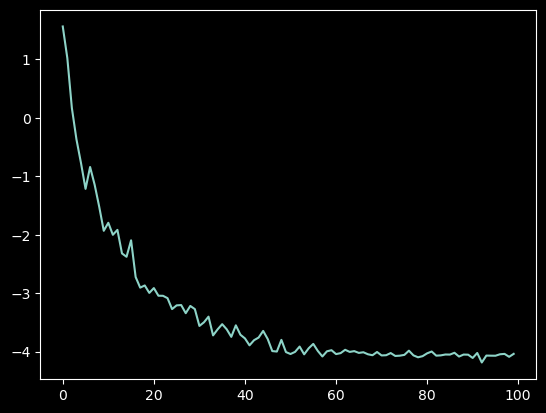

In [333]:
his = vmc_train_fermions(model, H, n_iter=100, n_samples=200, lr=5e-2)
plt.style.use("dark_background")
plt.plot(np.arange(0, 100), np.array(his).real)

In [17]:
# exact diagonalization
groundstate_ed_tv(3, 3, 2, 1, 1, pbc=False)

(np.float64(-4.085907017028026),
 array([ 0.10190528,  0.1773835 , -0.02127492,  0.13486382,  0.23329046,
        -0.03703262,  0.07585948,  0.151325  ,  0.10190528, -0.20603345,
        -0.04254983,  0.13486382, -0.18462148, -0.07406523,  0.07585948,
        -0.28767146, -0.20603345, -0.02127492, -0.23118144, -0.18462148,
        -0.03703262,  0.20381056,  0.354767  , -0.02127492,  0.13486382,
         0.23329046,  0.20381056, -0.20603345, -0.04254983,  0.13486382,
        -0.28767146, -0.20603345, -0.02127492,  0.10190528,  0.1773835 ,
         0.10190528]))


## Problem 7: Hidden Fermion Determinant States (HFDS)

We now build the most expressive ansatz of the day. The key idea is to augment the physical system with $N_h$ hidden fermions and construct a Slater determinant on the enlarged system.

The wavefunction amplitude is:

$$\psi(\sigma) = \det M(\sigma), \quad M(\sigma) = \begin{pmatrix} \phi_v & \phi_h \\ \chi_v(\sigma) & \chi_h(\sigma) \end{pmatrix}$$

- $\phi_v, \phi_h$: trainable parameter blocks (fixed, configuration-independent)
- $\chi_v(\sigma), \chi_h(\sigma)$: neural-network-generated rows (configuration-dependent)

The matrix $M(\sigma)$ has size $(N + N_h) \times (N + N_h)$.

In [339]:
# Problem 7: Hidden Fermion Determinant State (HFDS)

class HiddenFermionDeterminantState(nn.Module):
    """Determinant ansatz with additional hidden fermionic degrees of freedom."""

    def __init__(self, n_sites, n_fermions, n_hidden, hidden_dims=(32,)):
        super().__init__()
        self.n_sites = n_sites
        self.n_fermions = n_fermions
        self.n_hidden = n_hidden
        self.n_total = n_fermions + n_hidden

        # TODO:
        # - define the configuration-independent determinant blocks
        # - define a neural network that outputs the configuration-dependent hidden block

        # config independent phi block as trainable matrix
        phi0 = torch.randn(self.n_sites, self.n_total, dtype=torch.float64)
        self.phi = nn.Parameter(phi0)

        # neural network for chi block
        layers = []
        d_in = self.n_sites
        for d in hidden_dims:
            layers += [nn.Linear(d_in, d, dtype=torch.float64)]
            layers += [nn.ReLU()]
            d_in = d

        # output layer of neural network that can be reshaped to N_h x (N+N_h) matrix
        layers += [nn.Linear(d_in, self.n_hidden * self.n_total, dtype=torch.float64)]
        self.net = nn.Sequential(*layers)

    def forward(self, sigmas):
        """Evaluate the HFDS wavefunction amplitude for a batch of configurations."""
        # TODO:
        psis = torch.zeros(len(sigmas), dtype=float)

        for i, s in enumerate(sigmas):
            # make sure s is a tensor of float64
            if type(s) is not torch.Tensor:
                s = torch.tensor(s, dtype=torch.float64)
            if s.dtype is not torch.float64:
                s = s.to(dtype=torch.float64)

            # find the indices of occupied sites
            occ_sites = torch.where(s == 1)[0]

            # check that the number of occupied sites matches the number of fermions
            if len(occ_sites) != self.n_fermions:
                raise ValueError("Number of occupied sites in configuration does not match the number of fermions.")
            
            # slice the physical rows according to occupied sites
            phi_sliced = self.phi[occ_sites, :]     # shape N x (N+N_h)

            # generate hidden block from the neural network
            chi = self.net(s).reshape(self.n_hidden, self.n_total) # shape N_h x (N+N_h)

            # assemble the full determinant matrix M(sigma)
            M = torch.cat((phi_sliced, chi))    # shape (N+N_h) x (N+N_h)
                    
            # det M(sigma)
            psis[i] = torch.det(M)
        
        return psis
    
    def log_psi(self, sigmas):
        psis = self.forward(sigmas)
        amp = torch.abs(psis)
        log_amp = torch.log(amp)
        phase = torch.angle(psis)
        return log_amp, phase

# TODO:
# Train the HFDS ansatz with the same VMC machinery.
# Compare to ED and study the dependence on n_hidden / network depth.
# Optionally scan t/V and look for signatures of charge order.


In [340]:
# quick test
model = HiddenFermionDeterminantState(9, 2, 4, hidden_dims=(32, 32))
sigmas = build_fock_basis(9, 2)
s = sigmas[0]
# model.log_psi(torch.tensor([s]))
model.forward([s])

tensor([0.0167], dtype=torch.float64, grad_fn=<CopySlices>)

In [341]:
model = HiddenFermionDeterminantState(9, 2, 4, hidden_dims=(32,))
H = build_tv_hamiltonian(3, 3, 2, 1, 1, pbc=False)
basis_dict = build_basis_dict(build_fock_basis(model.n_sites, model.n_fermions))
samples_idx = metropolis_sampler_fermions(model, 10, 10, basis_dict=basis_dict)

C:\Users\Linus\AppData\Local\Temp\ipykernel_9932\3584973508.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  state = np.array(state)


C:\Users\Linus\AppData\Local\Temp\ipykernel_9932\3584973508.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  state = np.array(state)
C:\Users\Linus\AppData\Local\Temp\ipykernel_9932\211975836.py:145: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p.grad = torch.tensor(flat_grad[ptr:ptr+n].reshape(p.shape), dtype=p.dtype) # copy the corresponding slice of the flat gradient into p.grad


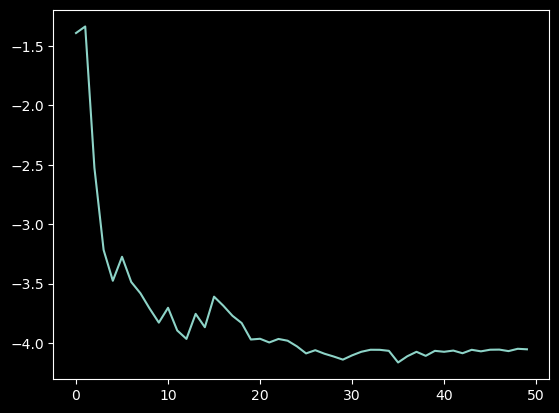

In [342]:
train_params = (50, 200, 1e-1)
# his = vmc_train_fermions(model, H, n_iter=50, n_samples=200, lr=1e-1)
his = vmc_train_fermions(model, H, *train_params)
plt.style.use("dark_background")
plt.plot(np.arange(0, 50), np.array(his).real)

In [364]:
H = build_tv_hamiltonian(3, 3, 2, 1, 1, pbc=False)
basis_dict = build_basis_dict(build_fock_basis(model.n_sites, model.n_fermions))
samples_idx = metropolis_sampler_fermions(model, 300, 100, basis_dict=basis_dict)
    
local_energy_tv(model, samples_idx, H, basis_dict).mean()

C:\Users\Linus\AppData\Local\Temp\ipykernel_9932\3584973508.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  state = np.array(state)


tensor(-4.0742, dtype=torch.float64)

## Problem 8: Comparison to Exact Results

We optimize the HFDS for different levels of model complexity, and then compare to the exact results. 


In [407]:
def run_scaling_study(system_params, model_params_list, training_params=(50, 200, 1e-1)):
    """
    Study how the variational energy depends on model complexity.

    system_params:      constant parameters of the physical system 
                        (Lx, Ly, N_f, t, V, pbc)
    model_params_list:  list of the model parameters to test
                        (n_hidden, hidden_dims)
    training_params:    parameters for vmc_train_fermions()
                        (n_iter=50, n_samples=200, lr=1e-1)
    """

    n_sites = system_params[0] * system_params[1]
    n_fermions = system_params[2]

    results = []
    histories = []

    for it, params in enumerate(model_params_list):
        print(f"Starting training {it+1} ...")

        # TODO: build model with given parameters
        model = HiddenFermionDeterminantState(n_sites, n_fermions, *params)
        H = build_tv_hamiltonian(*system_params)

        # TODO: run VMC optimization
        his = vmc_train_fermions(model, H, *training_params)
        histories += [his]

        # TODO: store final energy (and optionally other metrics)
        final_energy = his[-1]
        results += [final_energy]
        
        print(f"Training {it+1} finished with E={final_energy} \n")

    results = np.array(results)
    return results


# TODO:
# - define a range of model parameters
# - run scaling study
# - plot energy vs model complexity and compare to ED

In [408]:
sys_params = (3, 3, 4, 1, 1, False)
train_params = (100, 200, 1e-1)

n_hs = np.arange(1, 11)
model_params = []
for n in n_hs:
    model_params += [(n, (32,))]

energies = run_scaling_study(sys_params, model_params, train_params)

Starting training 1 ...


C:\Users\Linus\AppData\Local\Temp\ipykernel_9932\3584973508.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  state = np.array(state)
C:\Users\Linus\AppData\Local\Temp\ipykernel_9932\211975836.py:145: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p.grad = torch.tensor(flat_grad[ptr:ptr+n].reshape(p.shape), dtype=p.dtype) # copy the corresponding slice of the flat gradient into p.grad


Training 1 finished with E=-4.253566177060518 

Starting training 2 ...
Training 2 finished with E=-4.437697850399184 

Starting training 3 ...
Training 3 finished with E=-4.430212599412246 

Starting training 4 ...
Training 4 finished with E=-4.2690651926676075 

Starting training 5 ...
Training 5 finished with E=-4.349077757549121 

Starting training 6 ...
Training 6 finished with E=-3.486586182692859 

Starting training 7 ...
Training 7 finished with E=-4.449900160495137 

Starting training 8 ...
Training 8 finished with E=-4.423612673139958 

Starting training 9 ...
Training 9 finished with E=-3.469379487420407 

Starting training 10 ...
Training 10 finished with E=-2.83926010918678 



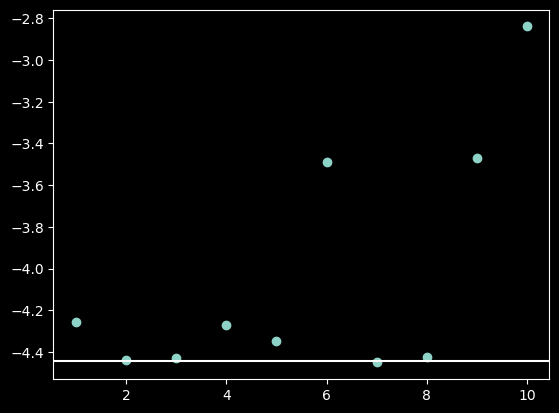

In [421]:
exact_energy = groundstate_ed_tv(*sys_params)[0]

plt.scatter(n_hs, energies)
plt.axhline(exact_energy)

## Problem 9: Locating the Phase Transition

We optimize the NQS for different values of $t/V$. 


In [ ]:
# Problem 9: scan over t/V and locate phase transition

def scan_phase_diagram(t_values, V, system_params):
    """
    Run VMC for different values of t/V and track observables.

    Goal: identify signatures of the phase transition.
    """

    observables = []

    for t in t_values:

        # TODO: build Hamiltonian with current t, V

        # TODO: optimize NQS (VMC)

        # TODO: measure relevant observables (e.g. density correlations)

        # TODO: store results

        pass

    return observables


# TODO:
# - choose a parameter range for t/V
# - run scan
# - plot observables vs t/V
# - identify transition point